In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("shimla_urban.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61392 entries, 0 to 61391
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               61392 non-null  int64  
 1   MO                 61392 non-null  int64  
 2   DY                 61392 non-null  int64  
 3   HR                 61392 non-null  int64  
 4   ALLSKY_SFC_SW_DWN  61392 non-null  float64
 5   T2M                61392 non-null  float64
 6   PRECTOTCORR        61392 non-null  float64
 7   WS10M              61392 non-null  float64
 8   PS                 61392 non-null  float64
 9   RH2M               61392 non-null  float64
 10  SZA                61392 non-null  float64
 11  ALLSKY_KT          61392 non-null  float64
dtypes: float64(8), int64(4)
memory usage: 5.6 MB


In [2]:
# df.isnull().sum()
(df == -999).sum()

YEAR                     0
MO                       0
DY                       0
HR                       0
ALLSKY_SFC_SW_DWN        0
T2M                      0
PRECTOTCORR              0
WS10M                    0
PS                       0
RH2M                     0
SZA                      0
ALLSKY_KT            29797
dtype: int64

In [3]:
print(df.columns)

Index(['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'T2M', 'PRECTOTCORR',
       'WS10M', 'PS', 'RH2M', 'SZA', 'ALLSKY_KT'],
      dtype='str')


In [4]:
df["datetime"] = pd.to_datetime(
    df[["YEAR", "MO", "DY", "HR"]].rename(columns={
        "YEAR":"year",
        "MO":"month",
        "DY":"day",
        "HR":"hour"
    })
)
df = df.sort_values("datetime")

In [5]:
df.replace(-999, np.nan, inplace=True)
df.dropna(inplace=True)
(df == -999).sum()

YEAR                 0
MO                   0
DY                   0
HR                   0
ALLSKY_SFC_SW_DWN    0
T2M                  0
PRECTOTCORR          0
WS10M                0
PS                   0
RH2M                 0
SZA                  0
ALLSKY_KT            0
datetime             0
dtype: int64

In [6]:
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["dayofyear"] = df["datetime"].dt.dayofyear

In [7]:
y = df["ALLSKY_SFC_SW_DWN"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [8]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [9]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
xgb_pred = xgb.predict(X_test)


In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))

r2 = r2_score(y_test,xgb_pred)

print("MAE : ",mae)
print("RMSE : " ,rmse)
print("R2_Score : ", r2)

MAE :  13.824372750680118
RMSE :  18.8245715793405
R2_Score :  0.9942870430443723


In [12]:
print(X.columns)
print("ALLSKY_SFC_SW_DWN" in X.columns)

print(X.columns.tolist())

Index(['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour',
       'month', 'dayofyear'],
      dtype='str')
False
['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour', 'month', 'dayofyear']


       Feature  Importance
0    ALLSKY_KT    0.652306
1          T2M    0.121883
5  PRECTOTCORR    0.105819
6         hour    0.077946
8    dayofyear    0.011488
2         RH2M    0.010391
4        WS10M    0.009397
7        month    0.008283
3           PS    0.002487


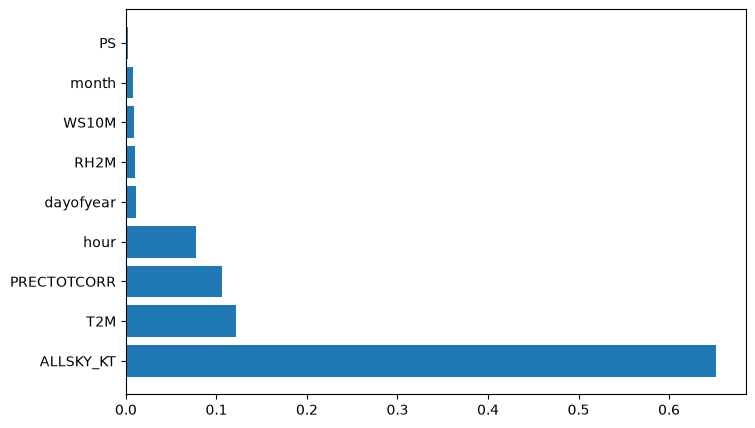

In [13]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

print("Correlation Analysis \n")

target_corr = (
    corr["ALLSKY_SFC_SW_DWN"].sort_values(ascending=False)
)
print(target_corr)

Correlation Analysis 

ALLSKY_SFC_SW_DWN    1.000000
ALLSKY_KT            0.797404
T2M                  0.472757
WS10M                0.366692
PS                   0.023326
DY                   0.009650
dayofyear           -0.011262
month               -0.011588
MO                  -0.011588
YEAR                -0.016731
HR                  -0.066366
hour                -0.066366
PRECTOTCORR         -0.133092
RH2M                -0.450898
SZA                 -0.818830
Name: ALLSKY_SFC_SW_DWN, dtype: float64


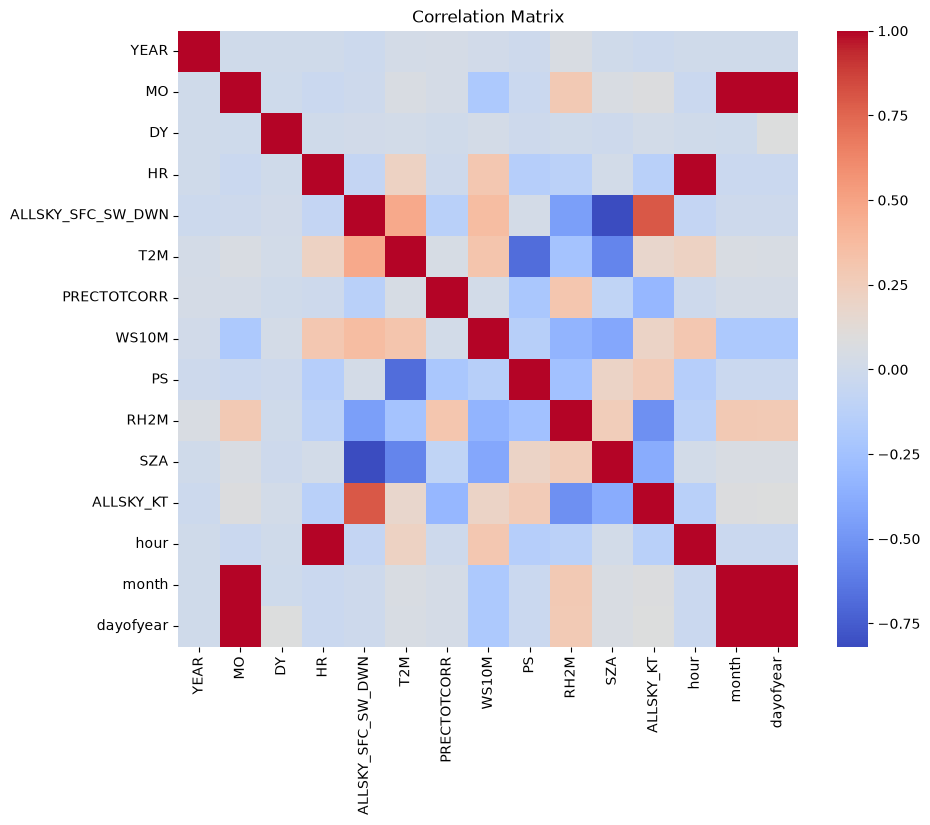

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr, 
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
df["target_1h"] = df["ALLSKY_SFC_SW_DWN"].shift(-1)
df["target_6h"] = df["ALLSKY_SFC_SW_DWN"].shift(-6)
df["target_12h"] = df["ALLSKY_SFC_SW_DWN"].shift(-12)
df["target_24h"] = df["ALLSKY_SFC_SW_DWN"].shift(-24)

df.dropna(inplace=True)


In [17]:
y = df["target_1h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [18]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
pred = xgb.predict(X_test)

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 25.452071528150086
RMSE : 38.073490631689374
R2 : 0.9766345557780219


In [22]:
y = df["target_6h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [23]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 64.48710353554117
RMSE : 91.65733943421472
R2 : 0.8646400124446018


In [26]:
y = df["target_6h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 64.48710353554117
RMSE : 91.65733943421472
R2 : 0.8646400124446018


In [27]:
y = df["target_12h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 78.52017207166607
RMSE : 112.06863691445646
R2 : 0.7975860284135146


In [28]:
y = df["target_24h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 93.87969680663129
RMSE : 127.8219536917325
R2 : 0.7366616899448601


In [29]:
results = pd.DataFrame({
    "Horizon":["1h", "6h", "12h", "24h"],
    "MAE":[25.452071528150086,64.48710353554117,78.52017207166607,93.87969680663129],
    "RMSE":[38.073490631689374,91.65733943421472,112.06863691445646,127.8219536917325],
    "R2":[0.9766345557780219,0.8646400124446018,0.7975860284135146,0.7366616899448601]
})

print(results)

  Horizon        MAE        RMSE        R2
0      1h  25.452072   38.073491  0.976635
1      6h  64.487104   91.657339  0.864640
2     12h  78.520172  112.068637  0.797586
3     24h  93.879697  127.821954  0.736662


In [30]:
xgb.fit(X_train,y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:02:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
train_residuals = y_train.values - xgb_train_pred
test_residuals = y_test.values - xgb_test_pred

print(train_residuals[:10])

[133.92584229  90.01473511  85.79951904  70.58586548  52.56311951
 -21.90101044 -36.36919434  73.95018616  65.15980713  10.68355103]


In [32]:
from sklearn.preprocessing import MinMaxScaler

res_scaler = MinMaxScaler()

train_residuals_scaled = res_scaler.fit_transform(
    train_residuals.reshape(-1,1)
)

test_residuals_scaled = res_scaler.transform(
    test_residuals.reshape(-1,1)
)

In [33]:
lookback = 24

import numpy as np

def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(len(data)-lookback):

        X.append(data[i:i+lookback])

        y.append(data[i+lookback])

    return np.array(X), np.array(y)

X_res_train, y_res_train = create_sequences(
    train_residuals_scaled,
    lookback
)

X_res_test, y_res_test = create_sequences(
    test_residuals_scaled,
    lookback
)

In [34]:
print(X_res_train.shape)
print(y_res_train.shape)

(25232, 24, 1)
(25232, 1)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [36]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(lookback,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_res_train,
    y_res_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0089 - val_loss: 0.0044
Epoch 2/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 3/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 4/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 5/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 6/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 7/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 8/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 9/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 10/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 11/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 12/40
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

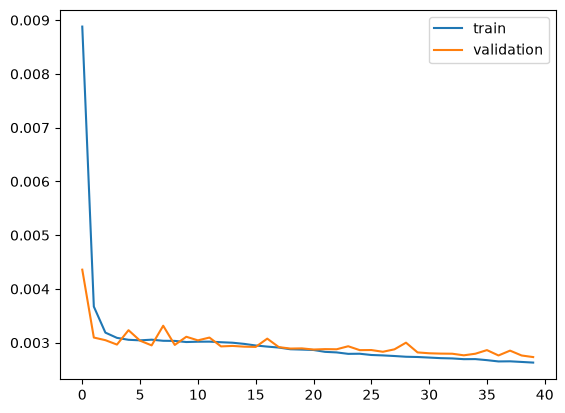

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

In [39]:
residual_pred_scaled = model.predict(
    X_res_test
)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [40]:
residual_pred = res_scaler.inverse_transform(
    residual_pred_scaled
)

In [41]:
lookback = 24
xgb_test_aligned = xgb_test_pred[lookback:]

y_test_aligned = y_test.values[lookback:]

hybrid_pred = (
    xgb_test_aligned
    +
    residual_pred.flatten()
)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_aligned,
    hybrid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_aligned,
        hybrid_pred
    )
)

r2 = r2_score(
    y_test_aligned,
    hybrid_pred
)

print("Hybrid MAE :", mae)
print("Hybrid RMSE :", rmse)
print("Hybrid R2 :", r2)

Hybrid MAE : 44.29360183527996
Hybrid RMSE : 58.90470431828144
Hybrid R2 : 0.944140935261478


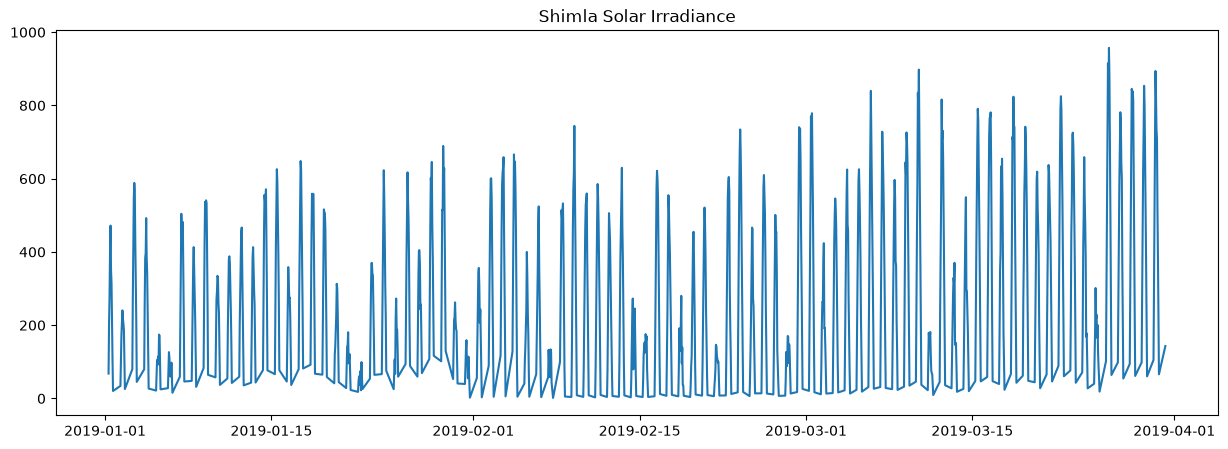

In [43]:
plt.figure(figsize=(15,5))

plt.plot(
    df["datetime"][:1000],
    df["ALLSKY_SFC_SW_DWN"][:1000]
)

plt.title("Shimla Solar Irradiance")
plt.show()